<a href="https://colab.research.google.com/github/GunelXelilli/Vendor-Analysis/blob/main/Vendors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

begin_inventory = pd.read_csv("/content/begin_inventory.csv")
end_inventory = pd.read_csv("/content/end_inventory.csv")
purchase_prices = pd.read_csv("/content/purchase_prices.csv")
purchases = pd.read_csv("/content/purchases.csv")
sales = pd.read_csv("/content/sales.csv")
vendor_invoice = pd.read_csv("/content/vendor_invoice.csv")
vendor_sales_summary = pd.read_csv("/content/vendor_sales_summary.csv")

In [ ]:
pd.set_option('display.max_columns', None)
begin_inventory.head()

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


In [ ]:
begin_inventory.shape

(206529, 9)

In [ ]:
begin_inventory.dtypes

,0
InventoryId,object
Store,int64
City,object
Brand,int64
Description,object
Size,object
onHand,int64
Price,float64
startDate,object


In [ ]:
begin_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206529 entries, 0 to 206528
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InventoryId  206529 non-null  object 
 1   Store        206529 non-null  int64  
 2   City         206529 non-null  object 
 3   Brand        206529 non-null  int64  
 4   Description  206529 non-null  object 
 5   Size         206529 non-null  object 
 6   onHand       206529 non-null  int64  
 7   Price        206529 non-null  float64
 8   startDate    206529 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 14.2+ MB


In [ ]:
begin_inventory.isnull().sum() #İnfo-dan da görsəndiyi kimi null dəyərlərimiz yoxdur

,0
InventoryId,0
Store,0
City,0
Brand,0
Description,0
Size,0
onHand,0
Price,0
startDate,0


In [ ]:
begin_inventory.duplicated().sum() #Dublikat dəyərlərimizdə yoxdur

np.int64(0)

In [ ]:
begin_inventory["City"] = begin_inventory["City"].str.title() #City adlarını Proper etdik

In [ ]:
import pandas as pd
import re

# copy ilə warning-ləri aradan qaldır
begin_inventory = begin_inventory.copy()

# Həcm hissəsini çıxarmaq
begin_inventory["Size_value"] = begin_inventory["Size"].str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Vahidi çıxarmaq
begin_inventory["Size_unit"] = begin_inventory["Size"].str.extract(r'([a-zA-Z]+)')[0].str.lower()

# L və Liter → ml çevrilməsi
begin_inventory.loc[begin_inventory["Size_unit"].isin(["l", "liter"]), "Size_value"] *= 1000
begin_inventory.loc[begin_inventory["Size_unit"].isin(["l", "liter"]), "Size_unit"] = "ml"

# Oz → ml çevrilməsi
begin_inventory.loc[begin_inventory["Size_unit"] == "oz", "Size_value"] *= 29.5735
begin_inventory.loc[begin_inventory["Size_unit"] == "oz", "Size_unit"] = "ml"

# Paket sayını çıxarmaq
def parse_pack(text):
    if pd.isna(text):
        return 1
    match = re.search(r'(\d+)\s*pk', text.lower())
    if match:
        return int(match.group(1))
    else:
        return 1

begin_inventory["Pack_num"] = begin_inventory["Size"].apply(parse_pack)

# Total volume (ml)
begin_inventory["Total_volume_ml"] = begin_inventory["Size_value"] * begin_inventory["Pack_num"]

# Artıq Size sütununu silmək
begin_inventory = begin_inventory.drop(columns=["Size"])

In [ ]:
begin_inventory["Size_unit"].unique()

array(['ml'], dtype=object)

In [ ]:
# Hər iki sütunda null olan sətirləri silirik
begin_inventory = begin_inventory.dropna(subset=["Size_value", "Size_unit"])

In [ ]:
begin_inventory.describe()

,Store,Brand,onHand,Price,Size_value,Pack_num,Total_volume_ml
count,202858.000000,202858.000000,202858.000000,202858.000000,202858.000000,202858.000000,202858.000000
mean,42.146285,13964.358379,20.521685,22.208268,913.187742,1.022898,916.690769
std,23.181822,13063.476264,31.661261,68.317769,609.202531,0.267601,607.172101
min,1.000000,58.000000,0.000000,0.000000,3.000000,1.000000,3.000000
25%,22.000000,3804.000000,7.000000,9.990000,750.000000,1.000000,750.000000
50%,42.000000,8092.000000,12.000000,14.990000,750.000000,1.000000,750.000000
75%,64.000000,22480.250000,21.000000,21.990000,750.000000,1.000000,750.000000
max,79.000000,90090.000000,1251.000000,13999.900000,20000.000000,12.000000,20000.000000


In [ ]:
begin_inventory.dtypes #Burada Id de herflerden ibaret oldugu ucun onu object tipli saxlayciq,ancaq startDate tarix Date formatina cevirecik


,0
InventoryId,object
Store,int64
City,object
Brand,int64
Description,object
onHand,int64
Price,float64
startDate,object
Size_value,float64
Size_unit,object


In [ ]:
begin_inventory["startDate"]=pd.to_datetime(begin_inventory["startDate"],errors='coerce')

In [ ]:
begin_inventory.dtypes

,0
InventoryId,object
Store,int64
City,object
Brand,int64
Description,object
onHand,int64
Price,float64
startDate,datetime64[ns]
Size_value,float64
Size_unit,object


END_INVENTORY

In [ ]:
end_inventory #burada gorunduyu kimi begin_inventory ile sutunlar eynidir sadece endDate var  bu faylda

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31
...,...,...,...,...,...,...,...,...,...
224484,81_PEMBROKE_90087,81,PEMBROKE,90087,Ch Mouton Rothschild 12 Paui,750mL,3,469.99,2024-12-31
224485,81_PEMBROKE_90088,81,PEMBROKE,90088,Ch Le Petite Mouton 12 Pauil,750mL,3,134.99,2024-12-31
224486,81_PEMBROKE_90089,81,PEMBROKE,90089,Ch Lynch Bages 12 Pauillac,750mL,3,119.99,2024-12-31
224487,81_PEMBROKE_90090,81,PEMBROKE,90090,Ch Lafite Rothschild 12,750mL,3,649.99,2024-12-31


In [ ]:
end_inventory.dtypes #burada enddate tipini Date edecik ve diger sutunlari silib begin_inventory ile merge edecik

,0
InventoryId,object
Store,int64
City,object
Brand,int64
Description,object
Size,object
onHand,int64
Price,float64
endDate,object


In [ ]:
end_inventory["endDate"]=pd.to_datetime(end_inventory["endDate"],errors='coerce')

In [ ]:
# end_inventory-də yalnız endDate və InventoryId qalacaq
end_inventory = end_inventory[["InventoryId", "endDate"]].copy()

# Step 3: begin_inventory və end_inventory-i InventoryId üzrə birləşdirmək
merged_inventory = pd.merge(
    begin_inventory,
    end_inventory,
    on="InventoryId",  # əsas sütun
    how="left"         # left join: begin_inventory-də olan bütün sətrlər qalacaq
)


In [ ]:
merged_inventory["endDate"] = merged_inventory["endDate"].fillna(merged_inventory["endDate"].mode()[0])

In [ ]:
merged_inventory = merged_inventory.drop(columns=["VendorName"], errors="ignore")

In [ ]:
merged_inventory

,InventoryId,Store,City,Brand,Description,onHand,Price,startDate,Size_value,Size_unit,Pack_num,Total_volume_ml,endDate
0,1_HARDERSFIELD_58,1,Hardersfield,58,Gekkeikan Black & Gold Sake,8,12.99,2024-01-01,750.0,ml,1,750.0,2024-12-31
1,1_HARDERSFIELD_60,1,Hardersfield,60,Canadian Club 1858 VAP,7,10.99,2024-01-01,750.0,ml,1,750.0,2024-12-31
2,1_HARDERSFIELD_62,1,Hardersfield,62,Herradura Silver Tequila,6,36.99,2024-01-01,750.0,ml,1,750.0,2024-12-31
3,1_HARDERSFIELD_63,1,Hardersfield,63,Herradura Reposado Tequila,3,38.99,2024-01-01,750.0,ml,1,750.0,2024-12-31
4,1_HARDERSFIELD_72,1,Hardersfield,72,No. 3 London Dry Gin,6,34.99,2024-01-01,750.0,ml,1,750.0,2024-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...
202853,79_BALLYMENA_46985,79,Ballymena,46985,Rodney Strong Cab Svgn Alexa,13,22.99,2024-01-01,750.0,ml,1,750.0,2024-12-31
202854,79_BALLYMENA_47014,79,Ballymena,47014,Juan Gil Jumilla Rd,13,13.99,2024-01-01,750.0,ml,1,750.0,2024-12-31
202855,79_BALLYMENA_47090,79,Ballymena,47090,Napa Cellars Cab Svgn Napa,19,23.99,2024-01-01,750.0,ml,1,750.0,2024-12-31
202856,79_BALLYMENA_90011,79,Ballymena,90011,Ch Pichon Longville 12 Pauil,12,144.99,2024-01-01,750.0,ml,1,750.0,2024-12-31


In [ ]:
merged_inventory.dtypes

,0
InventoryId,object
Store,int64
City,object
Brand,int64
Description,object
onHand,int64
Price,float64
startDate,datetime64[ns]
Size_value,float64
Size_unit,object


PURCHASE_PRICES

In [ ]:
purchase_prices # gorunduyu kimi burada da Size ve Volume sutunlarinda mueeyen problem var onlari dueldecik

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.
...,...,...,...,...,...,...,...,...,...
12256,44917,Ferreira 10-Yr Tawny Port,24.99,750mL,750,2,16.55,90024,VINILANDIA USA
12257,44944,Sanford Santa Rita Pnt Nr,22.99,750mL,750,2,14.93,4425,MARTIGNETTI COMPANIES
12258,45016,Neal One Lane Bridg Cab Svgn,93.99,750mL,750,2,61.43,10754,PERFECTA WINES
12259,46011,Folonari Pnt Nr Venezie,12.99,1500ml,1500,2,8.90,9744,FREDERICK WILDMAN & SONS


In [ ]:
purchase_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12261 entries, 0 to 12260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           12261 non-null  int64  
 1   Description     12260 non-null  object 
 2   Price           12261 non-null  float64
 3   Size            12260 non-null  object 
 4   Volume          12260 non-null  object 
 5   Classification  12261 non-null  int64  
 6   PurchasePrice   12261 non-null  float64
 7   VendorNumber    12261 non-null  int64  
 8   VendorName      12261 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 862.2+ KB


In [ ]:
purchase_prices.shape

(12261, 9)

In [ ]:
purchase_prices.dtypes

,0
Brand,int64
Description,object
Price,float64
Size,object
Volume,object
Classification,int64
PurchasePrice,float64
VendorNumber,int64
VendorName,object


In [ ]:
import pandas as pd
import re

purchase_prices = purchase_prices.copy()

purchase_prices["Size_value"] = purchase_prices["Size"].str.extract(r'(\d+\.?\d*)')[0].astype(float)
purchase_prices["Size_unit"] = purchase_prices["Size"].str.extract(r'([a-zA-Z]+)')[0].str.lower()

# L → ml
purchase_prices.loc[purchase_prices["Size_unit"].isin(["l","liter"]), "Size_value"] *= 1000
purchase_prices.loc[purchase_prices["Size_unit"].isin(["l","liter"]), "Size_unit"] = "ml"

# oz → ml
purchase_prices.loc[purchase_prices["Size_unit"]=="oz", "Size_value"] *= 29.5735
purchase_prices.loc[purchase_prices["Size_unit"]=="oz", "Size_unit"] = "ml"

def parse_pack(text):
    if pd.isna(text):
        return 1
    match = re.search(r'(\d+)\s*pk', str(text).lower())
    if match:
        return int(match.group(1))
    return 1

purchase_prices["Pack_num"] = purchase_prices["Size"].apply(parse_pack)

purchase_prices["Total_volume_ml"] = purchase_prices["Size_value"] * purchase_prices["Pack_num"]


purchase_prices = purchase_prices.drop(columns=["Size"])

In [ ]:
purchase_prices["Price_per_ml"] = purchase_prices["PurchasePrice"] / purchase_prices["Total_volume_ml"]

In [ ]:
purchase_prices["VendorName"]=purchase_prices["VendorName"].str.title()

In [ ]:
purchase_prices.isnull().sum()

,0
Brand,0
Description,1
Price,0
Volume,1
Classification,0
PurchasePrice,0
VendorNumber,0
VendorName,0
Size_value,5
Size_unit,1


In [ ]:
purchase_prices.dropna(subset=["Description","Volume","Size_value", "Size_unit", "Total_volume_ml", "Price_per_ml"], inplace=True)

In [ ]:
purchase_prices.isnull().sum()

,0
Brand,0
Description,0
Price,0
Volume,0
Classification,0
PurchasePrice,0
VendorNumber,0
VendorName,0
Size_value,0
Size_unit,0


In [ ]:
purchase_prices

,Brand,Description,Price,Volume,Classification,PurchasePrice,VendorNumber,VendorName,Size_value,Size_unit,Pack_num,Total_volume_ml,Price_per_ml
0,58,Gekkeikan Black & Gold Sake,12.99,750,1,9.28,8320,Shaw Ross Int L Imp Ltd,750.0,ml,1,750.0,0.012373
1,62,Herradura Silver Tequila,36.99,750,1,28.67,1128,Brown-Forman Corp,750.0,ml,1,750.0,0.038227
2,63,Herradura Reposado Tequila,38.99,750,1,30.46,1128,Brown-Forman Corp,750.0,ml,1,750.0,0.040613
3,72,No. 3 London Dry Gin,34.99,750,1,26.11,9165,Ultra Beverage Company Llp,750.0,ml,1,750.0,0.034813
4,75,Three Olives Tomato Vodka,14.99,750,1,10.94,7245,Proximo Spirits Inc.,750.0,ml,1,750.0,0.014587
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12256,44917,Ferreira 10-Yr Tawny Port,24.99,750,2,16.55,90024,Vinilandia Usa,750.0,ml,1,750.0,0.022067
12257,44944,Sanford Santa Rita Pnt Nr,22.99,750,2,14.93,4425,Martignetti Companies,750.0,ml,1,750.0,0.019907
12258,45016,Neal One Lane Bridg Cab Svgn,93.99,750,2,61.43,10754,Perfecta Wines,750.0,ml,1,750.0,0.081907
12259,46011,Folonari Pnt Nr Venezie,12.99,1500,2,8.90,9744,Frederick Wildman & Sons,1500.0,ml,1,1500.0,0.005933


In [ ]:
purchase_prices.dtypes

,0
Brand,int64
Description,object
Price,float64
Volume,object
Classification,int64
PurchasePrice,float64
VendorNumber,int64
VendorName,object
Size_value,float64
Size_unit,object


PURCHASES

In [ ]:
purchases

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2372469,49_GARIGILL_22298,49,22298,Zorvino Vyds Sangiovese,750mL,90058,ZORVINO VINEYARDS,13593,2024-12-19,2024-12-28,2025-01-09,2025-02-06,8.06,12,96.72,2
2372470,1_HARDERSFIELD_19556,1,19556,Zorvino Bacca Z Blackberry,750mL,90058,ZORVINO VINEYARDS,13593,2024-12-19,2024-12-27,2025-01-09,2025-02-06,9.39,12,112.68,2
2372471,66_EANVERNESS_22297,66,22297,Zorvino Vyds Pearz,750mL,90058,ZORVINO VINEYARDS,13593,2024-12-19,2024-12-26,2025-01-09,2025-02-06,6.75,12,81.00,2
2372472,69_MOUNTMEND_19557,69,19557,Zorvino Fragole Z Strawberry,750mL,90058,ZORVINO VINEYARDS,13593,2024-12-19,2024-12-26,2025-01-09,2025-02-06,9.39,12,112.68,2


In [ ]:
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2372474 entries, 0 to 2372473
Data columns (total 16 columns):
 #   Column          Dtype  
---  ------          -----  
 0   InventoryId     object 
 1   Store           int64  
 2   Brand           int64  
 3   Description     object 
 4   Size            object 
 5   VendorNumber    int64  
 6   VendorName      object 
 7   PONumber        int64  
 8   PODate          object 
 9   ReceivingDate   object 
 10  InvoiceDate     object 
 11  PayDate         object 
 12  PurchasePrice   float64
 13  Quantity        int64  
 14  Dollars         float64
 15  Classification  int64  
dtypes: float64(2), int64(6), object(8)
memory usage: 289.6+ MB


In [ ]:
purchases.dtypes

,0
InventoryId,object
Store,int64
Brand,int64
Description,object
Size,object
VendorNumber,int64
VendorName,object
PONumber,int64
PODate,object
ReceivingDate,object


In [ ]:
purchases.shape #stir sayimiz coxdur,data tiplerde bueyyen deyisikliklerden sonra bu probeme baxilacaq

(2372474, 16)

In [ ]:
date_cols = ["PODate", "ReceivingDate", "InvoiceDate", "PayDate"]

# Tarixləri datetime tipinə çevirmək
for col in date_cols:
    purchases[col] = pd.to_datetime(purchases[col], errors="coerce")

In [ ]:
purchases = purchases.drop(columns=["Size"], errors="ignore")

In [ ]:
purchases = purchases.drop(columns=["VendorName"], errors="ignore")

In [ ]:
purchases = purchases.drop(columns=["Description"], errors="ignore")

In [ ]:
purchases.isnull().sum()

,0
InventoryId,0
Store,0
Brand,0
VendorNumber,0
PONumber,0
PODate,0
ReceivingDate,0
InvoiceDate,0
PayDate,0
PurchasePrice,0


In [ ]:
purchases.dropna(subset=["PONumber", "ReceivingDate", "InvoiceDate", "PayDate","PurchasePrice","Quantity","Dollars","Classification"], inplace=True)

In [ ]:
purchases.duplicated().sum()

np.int64(0)

In [ ]:
purchases.dtypes

,0
InventoryId,object
Store,int64
Brand,int64
VendorNumber,int64
PONumber,int64
PODate,datetime64[ns]
ReceivingDate,datetime64[ns]
InvoiceDate,datetime64[ns]
PayDate,datetime64[ns]
PurchasePrice,float64


VENDOR_INVOICE

In [ ]:
vendor_invoice

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,NaN
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,NaN
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,NaN
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,NaN


In [ ]:
vendor_invoice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   object 
 2   InvoiceDate   5543 non-null   object 
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   object 
 5   PayDate       5543 non-null   object 
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 433.2+ KB


In [ ]:
vendor_invoice.shape

(5543, 10)

In [ ]:
vendor_invoice.dtypes

,0
VendorNumber,int64
VendorName,object
InvoiceDate,object
PONumber,int64
PODate,object
PayDate,object
Quantity,int64
Dollars,float64
Freight,float64
Approval,object


In [ ]:
date_cols = ["PODate", "InvoiceDate", "PayDate"]

for col in date_cols:
    vendor_invoice[col] = pd.to_datetime(vendor_invoice[col], errors="coerce")

In [ ]:
vendor_invoice["VendorName"]=vendor_invoice["VendorName"].str.title()

In [ ]:
vendor_invoice = vendor_invoice.drop(columns=["Approval"], errors="ignore")

In [ ]:
vendor_invoice.isnull().sum()

,0
VendorNumber,0
VendorName,0
InvoiceDate,0
PONumber,0
PODate,0
PayDate,0
Quantity,0
Dollars,0
Freight,0


In [ ]:
vendor_invoice.duplicated().sum()

np.int64(0)

In [ ]:
vendor_invoice.dtypes

,0
VendorNumber,int64
VendorName,object
InvoiceDate,datetime64[ns]
PONumber,int64
PODate,datetime64[ns]
PayDate,datetime64[ns]
Quantity,int64
Dollars,float64
Freight,float64


VENDOR_SALES_SUMMARY

In [ ]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,672819.31,5101919.51,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,561512.37,4819073.49,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,461140.15,4538120.60,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,420050.01,4475972.88,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,545778.28,4223107.62,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,10.96,15.95,0.55,27100.41,13.31,83.448276,2.500000,6.041667
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,1.47,65.66,7.04,50293.62,63.32,96.436186,22.333333,28.059829
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,0.99,1.98,0.10,14069.87,0.50,25.252525,1.000000,1.337838
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,77.61,143.28,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [ ]:
vendor_sales_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10692 entries, 0 to 10691
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorNumber           10692 non-null  int64  
 1   VendorName             10692 non-null  object 
 2   Brand                  10692 non-null  int64  
 3   Description            10692 non-null  object 
 4   PurchasePrice          10692 non-null  float64
 5   ActualPrice            10692 non-null  float64
 6   Volume                 10692 non-null  float64
 7   TotalPurchaseQuantity  10692 non-null  int64  
 8   TotalPurchaseDollars   10692 non-null  float64
 9   TotalSalesQuantity     10692 non-null  float64
 10  TotalSalesPrice        10692 non-null  float64
 11  TotalSalesDollars      10692 non-null  float64
 12  TotalExciseTax         10692 non-null  float64
 13  FreightCost            10692 non-null  float64
 14  GrossProfit            10692 non-null  float64
 15  Pr

In [ ]:
vendor_sales_summary.shape

(10692, 18)

In [ ]:
vendor_sales_summary.dtypes

,0
VendorNumber,int64
VendorName,object
Brand,int64
Description,object
PurchasePrice,float64
ActualPrice,float64
Volume,float64
TotalPurchaseQuantity,int64
TotalPurchaseDollars,float64
TotalSalesQuantity,float64


In [ ]:
vendor_sales_summary.isnull().sum()

,0
VendorNumber,0
VendorName,0
Brand,0
Description,0
PurchasePrice,0
ActualPrice,0
Volume,0
TotalPurchaseQuantity,0
TotalPurchaseDollars,0
TotalSalesQuantity,0


In [ ]:
vendor_sales_summary.duplicated().sum()

np.int64(0)

In [ ]:
vendor_sales_summary["VendorName"]=vendor_sales_summary["VendorName"].str.title()

In [ ]:
import numpy as np
import pandas as pd

vendor_sales_summary.loc[:, "ProfitMargin"] = (
    vendor_sales_summary["ProfitMargin"]
    .replace([float('inf'), float('-inf')], np.nan)
    .apply(lambda x: np.nan if pd.isna(x) else x)
    .astype(float)
)

In [ ]:
vendor_sales_summary.describe()

,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
count,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,1.069200e+04,10514.000000,10692.000000,10692.000000
mean,10650.649458,18039.228769,24.385303,35.643671,847.360550,3140.886831,3.010669e+04,3077.482136,18793.783627,4.223907e+04,1774.226259,61433.763214,1.213238e+04,-15.885227,1.706793,2.504390
std,18753.519148,12662.187074,109.269375,148.246016,664.309212,11095.086769,1.230678e+05,10952.851391,44952.773386,1.676553e+05,10975.582240,60938.458032,4.622434e+04,447.289882,6.020460,8.459067
min,2.000000,58.000000,0.360000,0.490000,50.000000,1.000000,7.100000e-01,0.000000,0.000000,0.000000e+00,0.000000,0.090000,-5.200278e+04,-23730.638953,0.000000,0.000000
25%,3951.000000,5793.500000,6.840000,10.990000,750.000000,36.000000,4.534575e+02,33.000000,289.710000,7.292200e+02,4.800000,14069.870000,5.292000e+01,15.353839,0.807229,1.153729
50%,7153.000000,18761.500000,10.455000,15.990000,750.000000,262.000000,3.655465e+03,261.000000,2857.800000,5.298045e+03,46.570000,50293.620000,1.399640e+03,30.778375,0.981529,1.436894
75%,9552.000000,25514.250000,19.482500,28.990000,750.000000,1975.750000,2.073824e+04,1929.250000,16059.562500,2.839692e+04,418.650000,79528.990000,8.660200e+03,40.210967,1.039342,1.665449
max,201359.000000,90631.000000,5681.810000,7499.990000,20000.000000,337660.000000,3.811252e+06,334939.000000,672819.310000,5.101920e+06,368242.800000,257032.070000,1.290668e+06,99.716657,274.500000,352.928571


In [ ]:
vendor_sales_summary.isnull().sum()

,0
VendorNumber,0
VendorName,0
Brand,0
Description,0
PurchasePrice,0
ActualPrice,0
Volume,0
TotalPurchaseQuantity,0
TotalPurchaseDollars,0
TotalSalesQuantity,0


In [ ]:
vendor_sales_summary = vendor_sales_summary.dropna(subset=["ProfitMargin"])


In [ ]:
vendor_sales_summary.dtypes

,0
VendorNumber,int64
VendorName,object
Brand,int64
Description,object
PurchasePrice,float64
ActualPrice,float64
Volume,float64
TotalPurchaseQuantity,int64
TotalPurchaseDollars,float64
TotalSalesQuantity,float64


SALES

In [ ]:
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,750mL,1.0,16.49,16.49,2024-01-01,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,750mL,2.0,32.98,16.49,2024-01-02,750.0,1.0,1.57,12546.0,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,750mL,1.0,16.49,16.49,2024-01-03,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,750mL,1.0,14.49,14.49,2024-01-08,750.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1.0,1005.0,Maker's Mark Combo Pack,375mL 2 Pk,2.0,69.98,34.99,2024-01-09,375.0,1.0,0.79,12546.0,JIM BEAM BRANDS COMPANY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11346054,76_DONCASTER_23415,76.0,23415.0,Darkhorse Svgn Bl,750mL,2.0,15.98,7.99,2024-11-20,750.0,2.0,0.22,3252.0,E & J GALLO WINERY
11346055,76_DONCASTER_23415,76.0,23415.0,Darkhorse Svgn Bl,750mL,1.0,7.99,7.99,2024-11-22,750.0,2.0,0.11,3252.0,E & J GALLO WINERY
11346056,76_DONCASTER_23415,76.0,23415.0,Darkhorse Svgn Bl,750mL,3.0,23.97,7.99,2024-11-25,750.0,2.0,0.34,3252.0,E & J GALLO WINERY
11346057,76_DONCASTER_23415,76.0,23415.0,Darkhorse Svgn Bl,750mL,1.0,7.99,7.99,2024-11-26,750.0,2.0,0.11,3252.0,E & J GALLO WINERY


In [ ]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11346059 entries, 0 to 11346058
Data columns (total 14 columns):
 #   Column          Dtype  
---  ------          -----  
 0   InventoryId     object 
 1   Store           float64
 2   Brand           float64
 3   Description     object 
 4   Size            object 
 5   SalesQuantity   float64
 6   SalesDollars    float64
 7   SalesPrice      float64
 8   SalesDate       object 
 9   Volume          float64
 10  Classification  float64
 11  ExciseTax       float64
 12  VendorNo        float64
 13  VendorName      object 
dtypes: float64(9), object(5)
memory usage: 1.2+ GB


In [ ]:
sales.shape

(11346059, 14)

In [ ]:
sales.dtypes

,0
InventoryId,object
Store,float64
Brand,float64
Description,object
Size,object
SalesQuantity,float64
SalesDollars,float64
SalesPrice,float64
SalesDate,object
Volume,float64


In [ ]:
sales.isnull().sum()

,0
InventoryId,0
Store,1
Brand,1
Description,1
Size,1
SalesQuantity,1
SalesDollars,1
SalesPrice,1
SalesDate,1
Volume,1


In [ ]:
df = sales[["Description","Brand","SalesQuantity","SalesDate","Volume","Classification","ExciseTax","Size","SalesPrice","SalesDollars","VendorNo","VendorName"]].dropna()

In [ ]:
sales["SalesPrice"].nunique()

411

In [ ]:
sales["SalesDollars"].nunique()

9864

In [ ]:
sales.duplicated().sum()

np.int64(0)

In [ ]:
sales["SalesDate"] = pd.to_datetime(sales["SalesDate"], errors="coerce")

In [ ]:
sales.drop(columns=["Size"], inplace=True)

In [ ]:
sales.drop(columns=["Volume"],inplace=True)

In [ ]:
sales["VendorName"]=sales["VendorName"].str.title()

In [ ]:
sales.dtypes

,0
InventoryId,object
Store,float64
Brand,float64
Description,object
SalesQuantity,float64
SalesDollars,float64
SalesPrice,float64
SalesDate,datetime64[ns]
Classification,float64
ExciseTax,float64


ANALYSIS

In [ ]:
sales["SalesDollars"].mean()

np.float64(34.87216352586947)

In [ ]:
sales["SalesDollars"].median()

18.99

Satışların paylanması sağa meyillidir (right-skewed). Yəni az sayda yüksək məbləğli satışlar ortalamanı (mean) artırır, amma satışların böyük hissəsi nisbətən aşağı məbləğlərdən ibarətdir

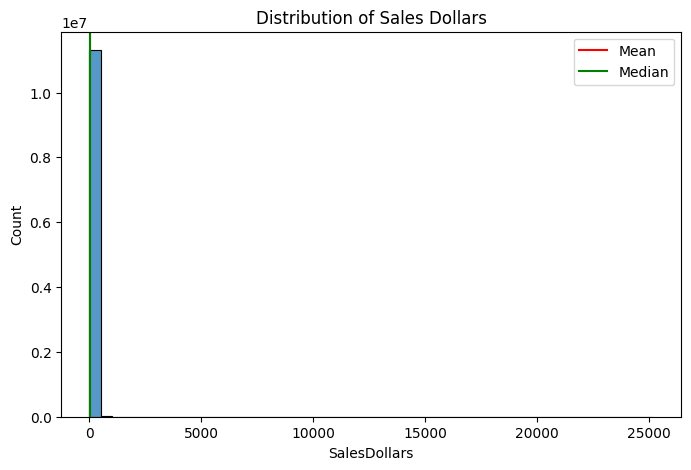

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(sales["SalesDollars"], bins=50)

plt.axvline(sales["SalesDollars"].mean(), color="red", label="Mean")
plt.axvline(sales["SalesDollars"].median(), color="green", label="Median")

plt.legend()
plt.title("Distribution of Sales Dollars")
plt.show() #outlierler coxdu deyene qrafik bele alinir indi kesim isi ile qrafiki duzeldecik

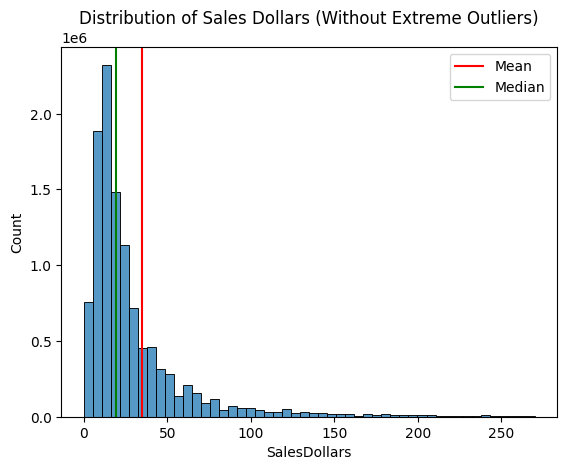

In [ ]:
limit = sales["SalesDollars"].quantile(0.99)

sns.histplot(sales[sales["SalesDollars"] < limit]["SalesDollars"], bins=50)

plt.axvline(sales["SalesDollars"].mean(), color="red", label="Mean")
plt.axvline(sales["SalesDollars"].median(), color="green", label="Median")

plt.legend()
plt.title("Distribution of Sales Dollars (Without Extreme Outliers)")
plt.show()

<Axes: xlabel='SalesDollars'>

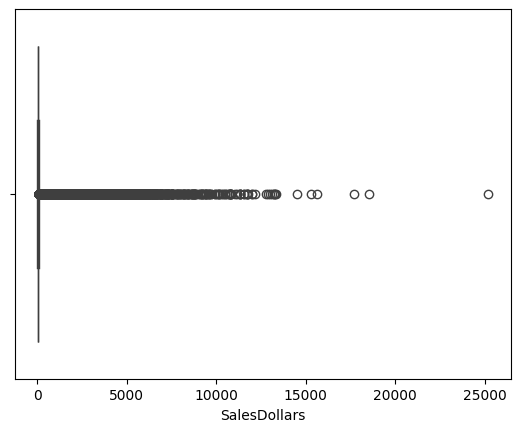

In [ ]:
sns.boxplot(x=sales["SalesDollars"])

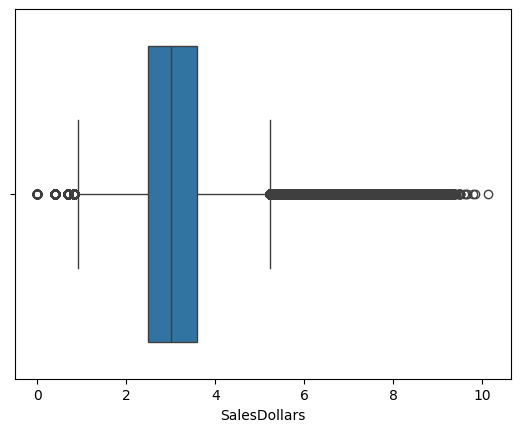

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Log transformasiya ilə boxplot
sns.boxplot(x=np.log1p(sales["SalesDollars"]))
plt.show()

<Axes: xlabel='SalesPrice'>

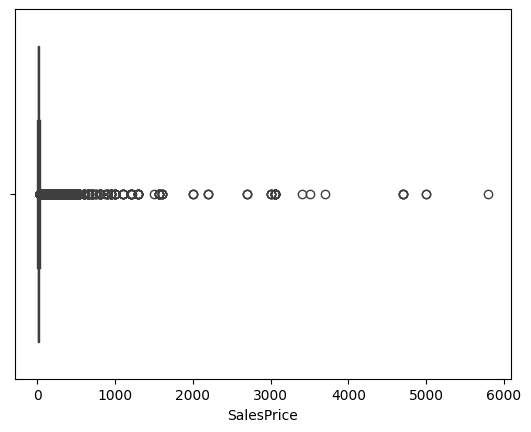

In [ ]:
sns.boxplot(x=sales["SalesPrice"])

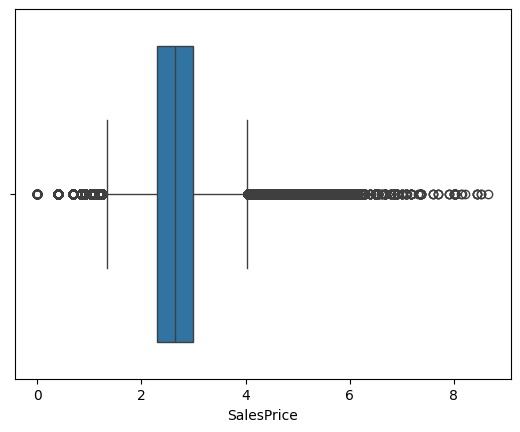

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Log transformasiya ilə boxplot
sns.boxplot(x=np.log1p(sales["SalesPrice"]))
plt.show()

In [ ]:
sales[["SalesPrice","SalesDollars"]].corr()

,SalesPrice,SalesDollars
SalesPrice,1.000000,0.287577
SalesDollars,0.287577,1.000000


In [ ]:
from scipy.stats import pearsonr
df = sales[["SalesPrice","SalesDollars"]].dropna()
corr, p_value = pearsonr(df["SalesPrice"], df["SalesDollars"])
print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.28757735425044745
p-value: 0.0


SalesPrice ilə SalesDollars arasında zəif müsbət əlaqə var (r ≈ 0.29). Bu o deməkdir ki, qiymət artdıqca gəlir müəyyən qədər artır

In [ ]:
sales["SalesDollars"].std()

87.70082823216563

SalesDollars üçün standart sapmanın yüksək olması (87.7) satışların çox dəyişkən olduğunu göstərir. Bu, dataset-də böyük fərqlər və outlier-lərin mövcud olduğunu göstərir və gəlirin az sayda yüksək dəyərli satışlardan təsirləndiyini göstərir

In [ ]:
product_sales = sales.groupby("Description")["SalesDollars"].sum().sort_values(ascending=False)

product_sales = product_sales.reset_index()

product_sales["cum_share"] = product_sales["SalesDollars"].cumsum() / product_sales["SalesDollars"].sum()

def abc(x):
    if x <= 0.7:
        return "A"
    elif x <= 0.9:
        return "B"
    else:
        return "C"

product_sales["ABC"] = product_sales["cum_share"].apply(abc)

In [ ]:
product_sales["ABC"].value_counts()

,count
ABC,
C,7885
B,1433
A,671


In [ ]:
product_sales.groupby("ABC")["SalesDollars"].sum()

,SalesDollars
ABC,
A,2.768613e+08
B,7.920911e+07
C,3.959122e+07


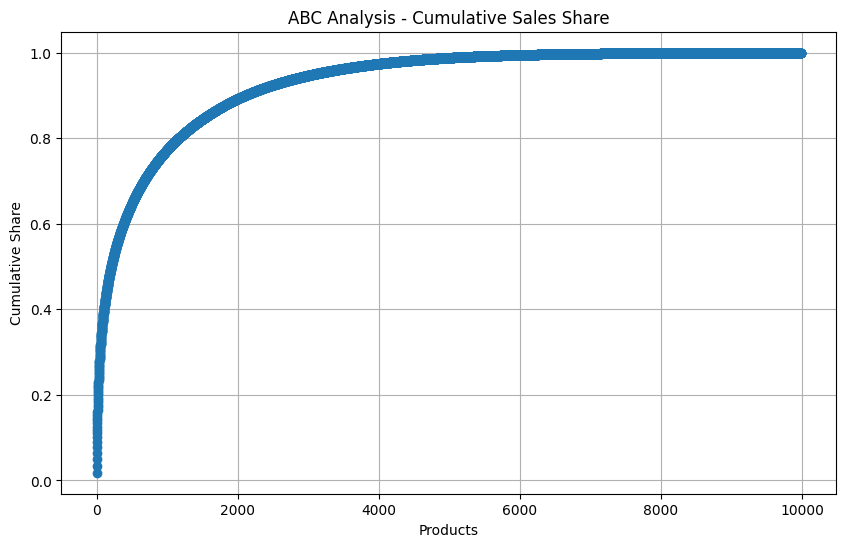

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(product_sales["cum_share"], marker='o')
plt.title("ABC Analysis - Cumulative Sales Share")
plt.xlabel("Products")
plt.ylabel("Cumulative Share")
plt.grid(True)
plt.show()

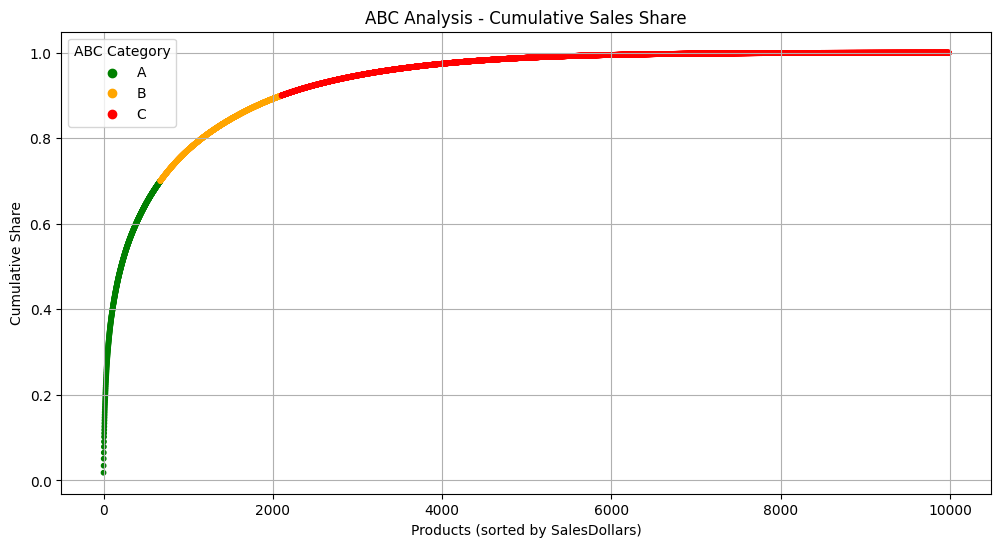

In [ ]:
import matplotlib.pyplot as plt

# Rengleri ABC kateqoriyalarına göre teyin edek
colors = product_sales["ABC"].map({"A": "green", "B": "orange", "C": "red"})

plt.figure(figsize=(12,6))
plt.scatter(range(len(product_sales)), product_sales["cum_share"], c=colors, s=10)
plt.title("ABC Analysis - Cumulative Sales Share")
plt.xlabel("Products (sorted by SalesDollars)")
plt.ylabel("Cumulative Share")
plt.grid(True)

# Legend elave etmek ucun dummy points
for label, color in {"A":"green","B":"orange","C":"red"}.items():
    plt.scatter([], [], c=color, label=label)
plt.legend(title="ABC Category")

plt.show() #Bu analiz göstərir ki, şirkətin gəlirinin böyük hissəsi məhsulların kiçik bir hissəsindən gəlir.

In [ ]:
# sales ilə birləşdirək
sales = sales.merge(product_sales[["Description", "ABC"]], on="Description", how="left")

In [ ]:
import pandas as pd

# CohortMonth və OrderMonth tam datetime, ayın 1-i kimi
sales["CohortMonth"] = sales.groupby("InventoryId")["SalesDate"].transform("min").dt.to_period("M").dt.to_timestamp()
sales["OrderMonth"] = sales["SalesDate"].dt.to_period("M").dt.to_timestamp()

# CohortIndex = neçə ay sonra
sales["CohortIndex"] = (sales["OrderMonth"].dt.year - sales["CohortMonth"].dt.year) * 12 + \
                       (sales["OrderMonth"].dt.month - sales["CohortMonth"].dt.month)

print(sales[["InventoryId", "SalesDate", "CohortMonth", "OrderMonth", "CohortIndex"]].head())

           InventoryId  SalesDate CohortMonth OrderMonth  CohortIndex
0  1_HARDERSFIELD_1004 2024-01-01  2024-01-01 2024-01-01          0.0
1  1_HARDERSFIELD_1004 2024-01-02  2024-01-01 2024-01-01          0.0
2  1_HARDERSFIELD_1004 2024-01-03  2024-01-01 2024-01-01          0.0
3  1_HARDERSFIELD_1004 2024-01-08  2024-01-01 2024-01-01          0.0
4  1_HARDERSFIELD_1005 2024-01-09  2024-01-01 2024-01-01          0.0


In [ ]:
sales["CohortIndex"] = sales["CohortIndex"].astype("Int64")  # nullable integer

In [ ]:
cohort_data = sales.groupby(["CohortMonth","CohortIndex"])["InventoryId"].nunique().reset_index()
cohort_table = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="InventoryId")
cohort_table

CohortIndex,0,1,2,3,4,5,6,7,8,9,10
CohortMonth,,,,,,,,,,,
2024-01-01,167283.0,141448.0,138882.0,137141.0,138638.0,137290.0,137722.0,133783.0,134171.0,131482.0,119368.0
2024-02-01,22848.0,13260.0,13115.0,13766.0,13569.0,13668.0,12852.0,12704.0,12034.0,10923.0,NaN
2024-03-01,10580.0,5839.0,6014.0,5847.0,5973.0,5490.0,5411.0,5065.0,4577.0,NaN,NaN
2024-04-01,7866.0,4763.0,4691.0,4662.0,4222.0,4044.0,3559.0,3216.0,NaN,NaN,NaN
2024-05-01,10241.0,6737.0,6684.0,5941.0,5680.0,4932.0,4534.0,NaN,NaN,NaN,NaN
2024-06-01,10680.0,6304.0,5642.0,5348.0,4771.0,4304.0,NaN,NaN,NaN,NaN,NaN
2024-07-01,7395.0,4849.0,4606.0,4046.0,3555.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-01,6776.0,4790.0,4375.0,3947.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-01,7460.0,5109.0,3190.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipykernel_526/2723745316.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TotalSalesDollars", y="VendorName", data=top_vendors, palette="viridis")


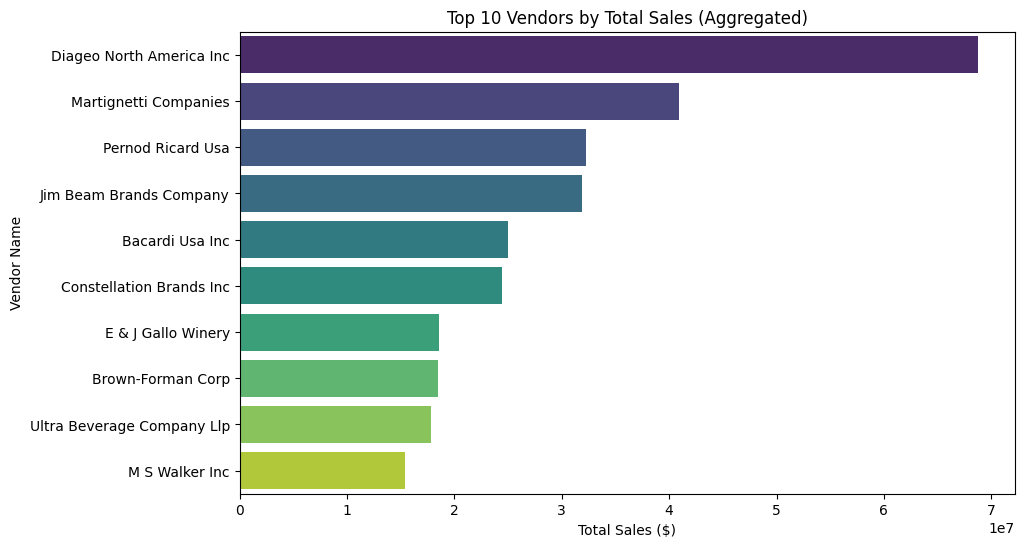

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# VendorName üzrə toplamaq
top_vendors = vendor_sales_summary.groupby("VendorName")[["TotalSalesDollars", "GrossProfit"]].sum()
top_vendors = top_vendors.sort_values("TotalSalesDollars", ascending=False).head(10)
top_vendors = top_vendors.reset_index()

# Barplot
plt.figure(figsize=(10,6))
sns.barplot(x="TotalSalesDollars", y="VendorName", data=top_vendors, palette="viridis")
plt.title("Top 10 Vendors by Total Sales (Aggregated)")
plt.xlabel("Total Sales ($)")
plt.ylabel("Vendor Name")
plt.show()

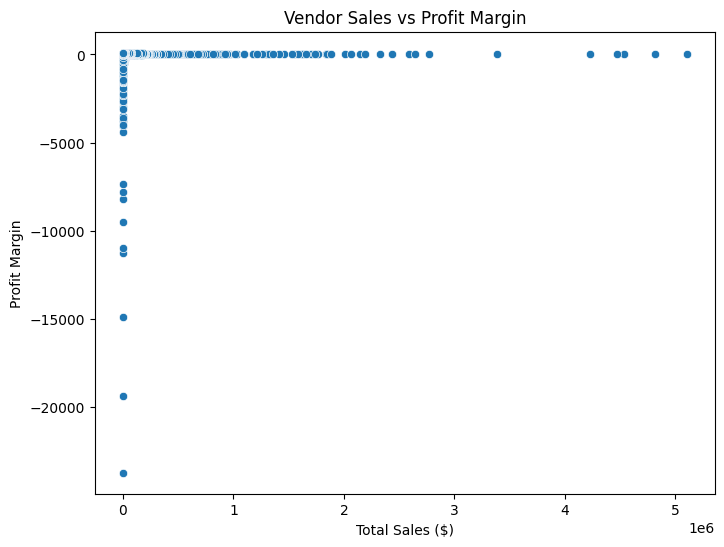

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="TotalSalesDollars",
    y="ProfitMargin",
    data=vendor_sales_summary
)
plt.title("Vendor Sales vs Profit Margin")
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin")
plt.show()

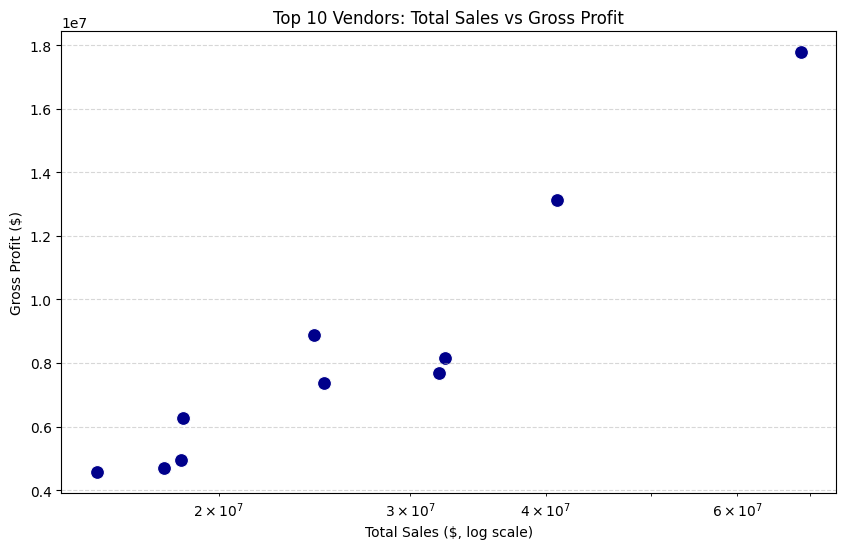

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Eyni vendor-ları toplamaq
top_vendors = vendor_sales_summary.groupby("VendorName")[["TotalSalesDollars", "GrossProfit"]].sum()
top_vendors = top_vendors.sort_values("TotalSalesDollars", ascending=False).head(10)
top_vendors = top_vendors.reset_index()

plt.figure(figsize=(10,6))
sns.scatterplot(
    x="TotalSalesDollars",
    y="GrossProfit",
    data=top_vendors,
    s=100,             # nöqtələrin ölçüsü
    color="darkblue"
)
plt.xscale("log")      # X oxunu log-scale-a çevir
plt.title("Top 10 Vendors: Total Sales vs Gross Profit")
plt.xlabel("Total Sales ($, log scale)")
plt.ylabel("Gross Profit ($)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

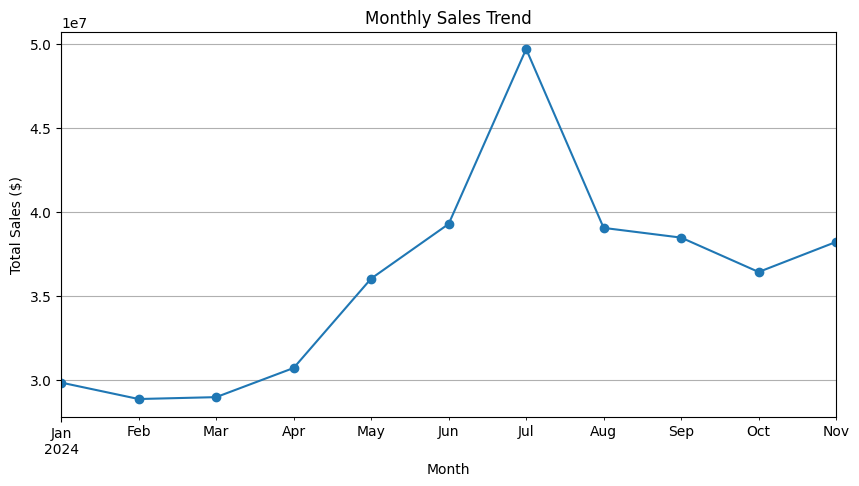

In [ ]:
sales["SalesDate"] = pd.to_datetime(sales["SalesDate"])

monthly_sales = sales.groupby(sales["SalesDate"].dt.to_period("M"))["SalesDollars"].sum()
monthly_sales.plot(figsize=(10,5), marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.grid(True)
plt.show()

<Axes: ylabel='Description'>

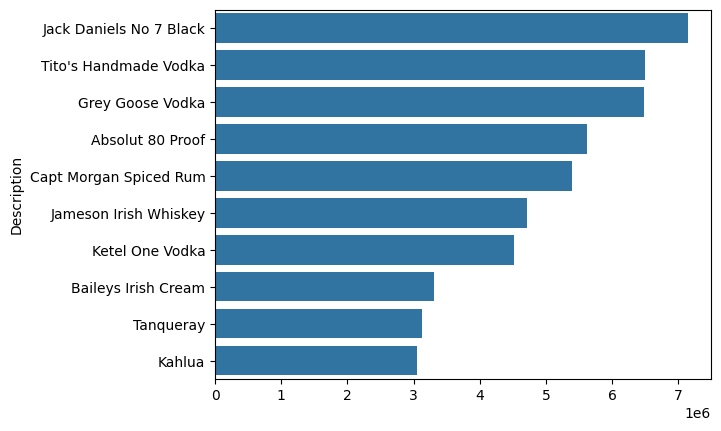

In [ ]:
top_products = sales.groupby("Description")["SalesDollars"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index)

In [ ]:
import pandas as pd

# CSV-lar
purchases_cleaned = pd.read_csv("purchases_cleaned.csv")
vendor_invoice_cleaned = pd.read_csv("vendor_invoice_cleaned.csv")
purchase_prices_cleaned = pd.read_csv("purchase_prices_cleaned.csv")

In [ ]:
# Hər fayldan VendorNumber və VendorName çıxar (purchases çıxarıldı)
vendor_invoice_vendors = vendor_invoice_cleaned[['VendorNumber', 'VendorName']]
purchase_prices_vendors = purchase_prices_cleaned[['VendorNumber', 'VendorName']]

# Bütün vendor-ları birləşdir
vendors_all = pd.concat([vendor_invoice_vendors, purchase_prices_vendors], ignore_index=True)

# Unikal vendor-lar
vendors_unique = vendors_all.drop_duplicates(subset=['VendorNumber'])

# VendorName boşdursa 'Unknown' qoy (warning-free)
vendors_unique.loc[:, 'VendorName'] = vendors_unique['VendorName'].fillna('Unknown')

# Sort
vendors_unique = vendors_unique.sort_values('VendorNumber')

# PostgreSQL üçün CSV
vendors_unique.to_csv("vendors.csv", index=False)

print(vendors_unique.head())

      VendorNumber                               VendorName
725            2.0  Ira Goldman And Williams, Llp          
5015          54.0              Aaper Alcohol & Chemical Co
1997          60.0              Adamba Imports Intl Inc    
0            105.0              Altamar Brands Llc         
2804         200.0              American Spirits Exchange  


In [ ]:
sales_cleaned.head()

,InventoryId,Store,Brand,Description,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Classification,ExciseTax,VendorNumber,VendorName,ABC,CohortMonth,OrderMonth,CohortIndex
0,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,1.0,16.49,16.49,2024-01-01,1.0,0.79,12546.0,Jim Beam Brands Company,C,2024-01-01,2024-01-01,0.0
1,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,2.0,32.98,16.49,2024-01-02,1.0,1.57,12546.0,Jim Beam Brands Company,C,2024-01-01,2024-01-01,0.0
2,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,1.0,16.49,16.49,2024-01-03,1.0,0.79,12546.0,Jim Beam Brands Company,C,2024-01-01,2024-01-01,0.0
3,1_HARDERSFIELD_1004,1.0,1004.0,Jim Beam w/2 Rocks Glasses,1.0,14.49,14.49,2024-01-08,1.0,0.79,12546.0,Jim Beam Brands Company,C,2024-01-01,2024-01-01,0.0
4,1_HARDERSFIELD_1005,1.0,1005.0,Maker's Mark Combo Pack,2.0,69.98,34.99,2024-01-09,1.0,0.79,12546.0,Jim Beam Brands Company,B,2024-01-01,2024-01-01,0.0


In [ ]:
import pandas as pd
import os
import zipfile
from google.colab import files

# Fayl siyahısı
csv_files = [
    "vendors.csv",
    "sales_cleaned.csv",
    "merged_inventory_cleaned.csv",
    "vendor_invoice_cleaned.csv",
    "vendor_sales_summary_cleaned.csv",
    "purchases_cleaned.csv",
    "purchase_prices_cleaned.csv"
]

pg_files = []

# Bütün CSV-ləri təmizlə və yeni CSV yarad
for f in csv_files:
    df = pd.read_csv(f)

    # String sütunlarda bütün boşluq və " ' işarələrini sil
    str_cols = df.select_dtypes(include='object').columns
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip()      # əvvəl və son boşluqları sil
        df[col] = df[col].str.replace('"', '')         # quotes sil
        df[col] = df[col].str.replace("'", '')         # varsa tək quote sil

    # Vendors üçün VendorNumber
    if f == "vendors.csv":
        # NaN-ları 0 ilə əvəz et və integer-a çevir
        df['VendorNumber'] = df['VendorNumber'].fillna(0).astype(int)

    # Yeni CSV faylı save et
    out_file = f.replace(".csv","_cleaned_pg.csv")
    df.to_csv(out_file, index=False)
    pg_files.append(out_file)

# Hamısını ZIP faylına yığ
zip_filename = "/content/all_csv_files_cleaned_pg.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in pg_files:
        zipf.write(file, arcname=os.path.basename(file))

#  ZIP faylını kompüterə endir
files.download(zip_filename)

print( "Bütün CSVlər təmizləndi ,NaN və quotes issues aradan qaldırıldı")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Bütün CSV-lər təmizləndi, NaN və quotes issues aradan qaldırıldı, ZIP hazırdır!


Hipotez testi

In [ ]:
import pandas as pd

df = pd.read_csv("/content/sales_cleaned_cleaned_pg.csv")

In [ ]:
df[["Classification", "SalesDollars"]].head()

,Classification,SalesDollars
0,1.0,16.49
1,1.0,32.98
2,1.0,16.49
3,1.0,14.49
4,1.0,69.98


In [ ]:
df = df.dropna(subset=["Classification", "SalesDollars"])

In [ ]:
group1 = df[df["Classification"] == 1]["SalesDollars"]
group2 = df[df["Classification"] == 2]["SalesDollars"]
#Burada klasifikasiyada 1 ve 2 ucun onlari qruplara ayirdiqki bize test rahat olsun

Hipotez testi (T-test)

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(group1, group2, equal_var=False) #equal_var=False daha real yanaşma

print("T-stat:", t_stat)
print("P-value:", p_value)
#Bu analizdə məqsəd Classification 1 və Classification 2 qrupları
#arasında satış (Dollars) baxımından statistik fərqin olub-olmadığını yoxlamadiq

#P-value çox kiçik olduğuna görə (p < 0.05), null hypothesis rədd edilir.
#Bu o deməkdir ki, iki qrup arasında statistik olaraq əhəmiyyətli fərq mövcuddur

T-stat: 32.53648797299673
P-value: 5.199334440629083e-232


In [ ]:
import numpy as np

mean1 = group1.mean()
mean2 = group2.mean()

std1 = group1.std()
std2 = group2.std()

cohens_d = (mean1 - mean2) / np.sqrt((std1**2 + std2**2) / 2)

print("Cohen's d:", cohens_d)
#Lakin Cohen’s d = 0.08 olduğu üçün effekt ölçüsü çox kiçikdir.
#Bu nəticə göstərir ki, qruplar arasında statistik fərq olsa da,
#bu fərq praktiki və biznes baxımından əhəmiyyətli deyil.

Cohen's d: 0.08289327247473577


Cohen’s d nəticəsi göstərir ki, iki qrup arasındakı fərq çox kiçikdir və biznes baxımından əhəmiyyətli təsir yaratmır. Bu o deməkdir ki, tətbiq olunan strategiya (məsələn, qiymət dəyişikliyi və ya kampaniya) satış davranışını ciddi şəkildə dəyişmir və resursların daha effektiv sahələrə yönəldilməsi daha məqsədəuyğun ola bilər.

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("H0 rədd olunur → fərq var ✅")
else:
    print("H0 rədd olunmur → fərq yoxdur ❌")

H0 rədd olunur → fərq var ✅


In [ ]:
print("Class 1 mean:", group1.mean())
print("Class 2 mean:", group2.mean())

Class 1 mean: 32.71771971118062
Class 2 mean: 27.63380614181841


Classification 1 və Classification 2 arasında satışlarda statistik olaraq fərq mövcuddur, lakin bu fərq çox zəifdir və biznes qərarlarına ciddi təsir göstərməyə bilər.

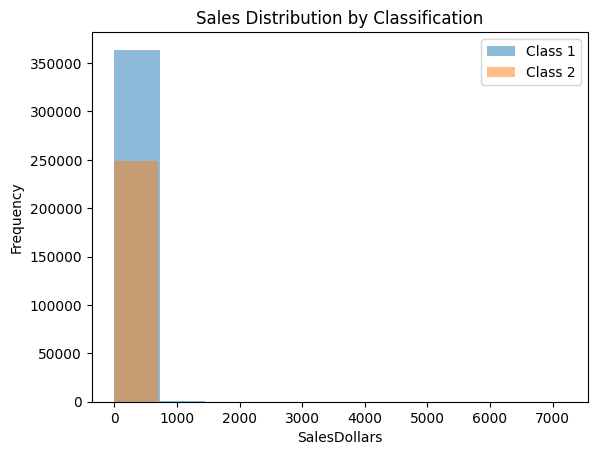

In [ ]:
import matplotlib.pyplot as plt
plt.hist(group1, alpha=0.5, label="Class 1")
plt.hist(group2, alpha=0.5, label="Class 2")
plt.legend()
plt.title("Sales Distribution by Classification")
plt.xlabel("SalesDollars")
plt.ylabel("Frequency")
plt.show()